In [4]:
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import pickle

from neuralhydrology.datasetzoo import get_dataset, camelsus
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.cudalstm import CudaLSTM
from neuralhydrology.modelzoo.shm import SHM
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.utils.config import Config
from neuralhydrology.training.basetrainer import BaseTrainer
from neuralhydrology.modelzoo.cfe_modules import get_pet

### Train the LSTM
To start, let's train an lstm for a single basin. If you're curious this is for the Narraguagus River with flow as measured at Cherryfield, Maine. I chose this for consistency with `examples/05-Inspecting-LSTMs`

In [5]:
config_file = Path("1_basin.yml")
#changed batch size to 1

In [6]:
config_file = Path("1_basin.yml")
# by default we assume that you have at least one CUDA-capable NVIDIA GPU or MacOS with Metal support
if torch.cuda.is_available() or torch.backends.mps.is_available():
     start_run(config_file=config_file)

 # fall back to CPU-only mode
else:
     start_run(config_file=config_file, gpu=-1)

2026-03-13 11:22:30,445: Logging to /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/09-Data-Assimilation/runs/test_run_1303_112230/output.log initialized.
2026-03-13 11:22:30,445: ### Folder structure created at /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/09-Data-Assimilation/runs/test_run_1303_112230
2026-03-13 11:22:30,445: ### Run configurations for test_run
2026-03-13 11:22:30,446: experiment_name: test_run
2026-03-13 11:22:30,446: train_basin_file: 1_basin.txt
2026-03-13 11:22:30,446: validation_basin_file: 1_basin.txt
2026-03-13 11:22:30,446: test_basin_file: 1_basin.txt
2026-03-13 11:22:30,447: train_start_date: 1999-10-01 00:00:00
2026-03-13 11:22:30,447: train_end_date: 2008-09-30 00:00:00
2026-03-13 11:22:30,447: validation_start_date: 1980-10-01 00:00:00
2026-03-13 11:22:30,447: validation_end_date: 1989-09-30 00:00:00
2026-03-13 11:22:30,447: test_start_date: 1989-10-01 00:00:00
2026-03-13 11:22:30,44

### Load up trained model
The results of training (model weights, metadata, and optimizer-related data) are saved in `runs`. Let's load them up.

In [7]:
run_dir = Path("runs/test_run_1203_222017")  # this value comes from the output of the above command
#!ls $run_dir/model_epoch* | tail -n 3

### Load up trained model
Let's create a new instance of the neural network and then load the trained weights into it.

In [8]:
cudalstm_config = Config(config_file)

# create a new model instance with random weights
cuda_lstm = CudaLSTM(cfg=cudalstm_config)

# load the trained weights into the new model. 
model_path = run_dir / 'model_epoch030.pt'
model_weights = torch.load(str(model_path), map_location='cpu')  # load the weights from the file, creating the weight tensors on CPU
cuda_lstm.load_state_dict(model_weights)  # set the new model's weights to the values loaded from file
cuda_lstm

FileNotFoundError: [Errno 2] No such file or directory: 'runs/test_run_1203_222017/model_epoch030.pt'

### Configuring SHM
Now, let's initialize an SHM model.

In [ ]:
shm_config_file = Path("shm_config.yml")
shm_config = Config(shm_config_file)
shm = SHM(cfg=shm_config)

### Fetch the data
Lets instantiate a dataloader containing the data we want

In [ ]:
# ! this returns data that is shuffled by date
trainer = BaseTrainer(cfg = Config(config_file))
trainer.initialize_training()
loader = trainer.loader


In [ ]:
#get data not shuffled by directly getting a DataLoader
scaler = load_scaler(run_dir )
ds = get_dataset(cfg = Config(config_file), is_train = False, basin = "01022500", period = 'test', scaler=scaler)
ordered_data = DataLoader(ds, batch_size= 1, shuffle=False, num_workers= 8, collate_fn=ds.collate_fn)
itable = list(ordered_data)

In [ ]:
data_point = itable[-1]

In [ ]:
# undo scaling
raw_x_d = {}
for feature, scaled in data_point['x_d'].items(): # key, value in dict
    center = float(scaler['xarray_feature_center'][feature].values)
    scale = float(scaler['xarray_feature_scale'][feature].values)
    raw_tensor = scaled * scale + center 
    raw_x_d[feature] = raw_tensor 

print("Scaled tmax range:", data_point['x_d']['tmax(C)'].min(), "to", data_point['x_d']['tmax(C)'].max())

center = float(scaler['xarray_feature_center']['QObs(mm/d)'].values)
scale = float(scaler['xarray_feature_scale']['QObs(mm/d)'].values)
raw_y = data_point['y'] * scale + center  

# Create a new dict with raw data, same structure as data_point
raw_data_point = {
    'x_d': raw_x_d,  
    'y': raw_y,    
    'date': data_point['date'], 
}

print("Raw tmax range:", raw_data_point['x_d']['tmax(C)'].min(), "to", raw_data_point['x_d']['tmax(C)'].max())  


Scaled tmax range: tensor(-2.1816) to tensor(2.0519)
Raw tmax range: tensor(-10.6200) to tensor(33.8900)


In [ ]:
print(data_point.keys())

dict_keys(['x_d', 'x_d_hindcast', 'x_d_forecast', 'y', 'date'])


In [ ]:
print(data_point['x_d'].keys())

dict_keys(['prcp(mm/day)', 'srad(W/m2)', 'tmax(C)', 'tmin(C)', 'vp(Pa)'])


In [ ]:
print(data_point['x_d']['tmax(C)'].shape)

In [ ]:
print(data_point['x_d']['tmax(C)'][0:5,0:2,:])

tensor([[[0.7108],
         [0.3275]]])


In [ ]:
print(data_point['y'].shape)
print(data_point['y'])

In [ ]:
print(data_point['date'].shape)
print(data_point['date'])


(1, 365)
[['1998-10-01T00:00:00.000000' '1998-10-02T00:00:00.000000'
  '1998-10-03T00:00:00.000000' '1998-10-04T00:00:00.000000'
  '1998-10-05T00:00:00.000000' '1998-10-06T00:00:00.000000'
  '1998-10-07T00:00:00.000000' '1998-10-08T00:00:00.000000'
  '1998-10-09T00:00:00.000000' '1998-10-10T00:00:00.000000'
  '1998-10-11T00:00:00.000000' '1998-10-12T00:00:00.000000'
  '1998-10-13T00:00:00.000000' '1998-10-14T00:00:00.000000'
  '1998-10-15T00:00:00.000000' '1998-10-16T00:00:00.000000'
  '1998-10-17T00:00:00.000000' '1998-10-18T00:00:00.000000'
  '1998-10-19T00:00:00.000000' '1998-10-20T00:00:00.000000'
  '1998-10-21T00:00:00.000000' '1998-10-22T00:00:00.000000'
  '1998-10-23T00:00:00.000000' '1998-10-24T00:00:00.000000'
  '1998-10-25T00:00:00.000000' '1998-10-26T00:00:00.000000'
  '1998-10-27T00:00:00.000000' '1998-10-28T00:00:00.000000'
  '1998-10-29T00:00:00.000000' '1998-10-30T00:00:00.000000'
  '1998-10-31T00:00:00.000000' '1998-11-01T00:00:00.000000'
  '1998-11-02T00:00:00.000000' 

In [ ]:
shm_parameters = {
            "dd": torch.tensor(5.0, device="cpu", dtype=torch.float32),
            "f_thr": torch.tensor(10.0, device="cpu", dtype=torch.float32),
            "sumax": torch.tensor(25.0, device="cpu", dtype=torch.float32),
            "beta": torch.tensor(5.0, device="cpu", dtype=torch.float32),
            "perc": torch.tensor(0.5, device="cpu", dtype=torch.float32),
            "kf": torch.tensor(3.0, device="cpu", dtype=torch.float32),
            "ki": torch.tensor(5.0, device="cpu", dtype=torch.float32),
            "kb": torch.tensor(15.0, device="cpu", dtype=torch.float32),
        }

In [ ]:
ss, sf, su, si, sb = shm.initialize_states(batch_size=256, device = 'cpu')

In [ ]:
def make_linear_M(ss, sf, su, si, sb, shm_parameters, x_conceptual_timestep, device):
    n_basins = ss.shape[0]
    M = torch.zeros(n_basins, 6, 6)
    M[:,5,5] =1
    zeros = torch.zeros_like(ss)
    ones = torch.ones_like(ss)

    # auxiliary vectors
    t_mean = (x_conceptual_timestep[:, 2] + x_conceptual_timestep[:, 3]) / 2
    temp_mask = t_mean < 0 # True when it is freezing
    snow_melt = t_mean * shm_parameters["dd"]
    snow_melt = torch.where(temp_mask, zeros, snow_melt) #torch.where(condition, input, other, *, out=None) → Tensor Return a tensor of elements selected from either input or other, depending on condition.
    
    klu = torch.tensor(0.90, device=device, dtype=torch.float32)

    # liquid precipitation:
    liquid_p = torch.where(temp_mask, zeros, x_conceptual_timestep[:,0])

    # solid precipitation (snow):
    snow = torch.where(temp_mask, x_conceptual_timestep[:,0], zeros)

    # permanent wilting point use in ET:
    pwp = 0.8 * shm_parameters["sumax"]

    # Snow module --------------------------
    qs_out = torch.minimum(ss, snow_melt) #cant melt more snow than there is
    qsp_out = qs_out + liquid_p

    M[:,0,0] = torch.where(snow_melt > ss, zeros, ones)
    M[:,0,5] = torch.where(snow_melt > ss, zeros, -snow_melt)

    
    dqsp_dss = torch.where(snow_melt> ss, ones, zeros) #if all the snow melts, then liquid is ss + P

    # Split snowmelt+rainfall into inflow to fastflow reservoir and unsaturated reservoir ------
    qf_in = torch.maximum(torch.tensor(0.0), qsp_out - shm_parameters["f_thr"])
    qu_in = torch.minimum(qsp_out, ones*shm_parameters["f_thr"])

    dqf_dss = torch.where(qsp_out > ones*shm_parameters["f_thr"], dqsp_dss, zeros) # if the liquid is greater than the saturation threshold then fast flow depends on liquid
    dqu_dss = torch.where(qsp_out > ones*shm_parameters["f_thr"], zeros, dqsp_dss) # if the liquid is less than the saturation threshold, then the unsaturated zone depends on liquid


    # Fastflow module ----------------------
    #    sf = (sf + qf_in) - (sf + qf_in) / shm_parameters["kf"] = (1 - 1/shm_parameters["kf"])(sf + qf_in)
    M[:, 1,0] = (1 - 1/shm_parameters["kf"])*dqf_dss # if liquid is ss
    M[:, 1,1] = (1 - 1/shm_parameters["kf"])
    M[:, 1,5] = (1 - 1/shm_parameters["kf"])*(qf_in - dqf_dss*ss) # 

    # Unsaturated zone----------------------
    psi = (su / shm_parameters["sumax"]) ** shm_parameters["beta"]
    dpsi_dsu = (shm_parameters["beta"]/shm_parameters["sumax"])*(su / shm_parameters["sumax"]) ** (shm_parameters["beta"]-1)
    su_temp = su + qu_in * (1 - psi)
    su = torch.minimum(su_temp, ones*shm_parameters["sumax"])

    dsut1_dsu = torch.where(su_temp > ones*shm_parameters["sumax"], zeros, 1 - qu_in*dpsi_dsu)
    dsut1_dss = torch.where(su_temp > ones*shm_parameters["sumax"], zeros, dqu_dss*(1-psi))
    su_const = torch.where(su_temp > ones*shm_parameters["sumax"], ones*shm_parameters["sumax"], qu_in*psi)

    qu_out = qu_in * psi + torch.maximum(torch.tensor(0.0), su_temp - shm_parameters["sumax"])  # [mm]
    dqu_out_dsu = torch.where(su_temp > ones*shm_parameters["sumax"], ones, qu_in*dpsi_dsu)
    dqu_out_dss = torch.where(su_temp > ones*shm_parameters["sumax"], dqu_dss, dqu_dss*psi)


    # Evapotranspiration -------------------
    # su_new = max(0, su_new - ret)
    ktetha = su / shm_parameters["sumax"]
    et_mask = su <= pwp
    ktetha[~et_mask] = torch.ones_like(ktetha[~et_mask]) # ktetha = su/sumax if su < pwp otherwise 1
    #if self.cfg.dataset == "camels_us":
    #    pet = get_pet.daily_pet_jensen2016(
    #        T_avg=t_mean,
    #        S_rad=x_conceptual_timestep[:, 1],
    #    ).to(device)
    #else:
    #    pet = x_conceptual_timestep[:, :, 1]
    pet = x_conceptual_timestep[:, 1]
    ret = pet * klu * ktetha  # [mm]
    dret_dsu = torch.where(su < pwp , ones*pet*klu/shm_parameters["sumax"], zeros)
    dsut1_dsu = dsut1_dsu - dret_dsu
    su_const = torch.where(su < pwp, su_const, su_const - ret)
    #su = torch.maximum(torch.tensor(0.0), su - ret)  if all the water evaporates# [mm]
    dsut1_dsu = torch.where((su - ret) > 0, dsut1_dsu, zeros)
    dsut1_dss = torch.where((su - ret) > 0, dsut1_dss, zeros)
    su_const = torch.where((su - ret) >0, su_const, zeros)

    M[:,2,0] = dsut1_dss
    M[:,2,2] = dsut1_dsu
    M[:,2,5] = su_const - dsut1_dss*ss - dsut1_dsu*su



    # Interflow reservoir ------------------
    #si = (si + qu_out * shm_parameters["perc"])*( 1 - 1/ shm_parameters["ki"])  # [mm]
    M[:,3,0] = (1 - 1/shm_parameters["ki"])*shm_parameters["perc"]*dqu_out_dss
    M[:,3,2] = (1 - 1/shm_parameters["ki"])*shm_parameters["perc"]*dqu_out_dsu
    M[:,3,3] = (1 - 1/shm_parameters["ki"])
    M[:,3,5] =  (1 - 1/shm_parameters["ki"])*shm_parameters["perc"]*(qu_out - dqu_out_dsu*su - dqu_out_dss*ss)

    # Baseflow reservoir -------------------
    #sb = (sb + qu_out * (1.0 - shm_parameters["perc"]))(1 - 1/shm_parameters["kb"])
    M[:,4,0] = (1 - 1/shm_parameters["kb"])*(1 - shm_parameters["perc"])*dqu_out_dss
    M[:,4,2] = (1 - 1/shm_parameters["kb"])*(1 - shm_parameters["perc"])*dqu_out_dsu
    M[:,4,4] = (1 - 1/shm_parameters["kb"])
    M[:,4,5] =  (1 - 1/shm_parameters["kb"])*(1 - shm_parameters["perc"])*(qu_out - dqu_out_dsu*su - dqu_out_dss*ss)

    return M


In [ ]:
## ToDo:
# 1. Fetch decent parameters, or make them up.
# 1.5 initialize the data loader. 
# 2. use shm.timestep in a for loop.
# 3. How do I connect this to forcings?

In [ ]:
#Test make linear M
t = 0
t_mean = (data_point['x_d']['tmax(C)'][:, t] + data_point['x_d']['tmin(C)'][:, t])/2
pet = get_pet.daily_pet_jensen2016(
                T_avg=t_mean,
                S_rad=data_point['x_d']['srad(W/m2)'][:,t],
            )
x_conceptual_timestep = torch.stack([
    data_point['x_d']['prcp(mm/day)'][:, t],
    pet,
    data_point['x_d']['tmin(C)'][:, t],
    data_point['x_d']['tmax(C)'][:, t],
], dim=1)
x_conceptual_timestep = x_conceptual_timestep.squeeze(-1)

M = make_linear_M(ss,sf,su,si,sb,shm_parameters, x_conceptual_timestep, device = "cpu")
print(M[1,:,:])

In [ ]:
# for loop

pt = raw_data_point #ordered_data[1]
dates = pt['date'] #[1,365]
ys = pt["y"] #[1,365,1]
x_d = pt['x_d'] # dict of forcing params mapped to [1,365,1]

# intitialize states for shm, total guess??
x = torch.tensor([0.0,1.0,5.0,10.0,15.0],dtype = torch.float32, device = "cpu")
x_history = np.zeros((6,365)) # to plot, = [ss, sf, su, si, sb, z_minus, ]

for j in range(ys.shape[1]): #each day
    date = dates[0, j]
    y = ys[0 ,j, 0] # true observed outflow not needed but could compare
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(x_d['tmax(C)'][0, j,0] + x_d['tmin(C)'][0, j,0])/2,
                S_rad= x_d['srad(W/m2)'][0,j,0],
            )
    x_conceptual_timestep = np.stack([x_d["prcp(mm/day)"][0,j,0], pet, x_d["tmin(C)"][0,j,0], x_d["tmax(C)"][0,j,0]])
    x_conceptual_timestep = torch.tensor(x_conceptual_timestep, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0) # size [1,4] row vector
    x[0], x[1], x[2], x[3], x[4], z_minus = shm.timestep_shm(x[0], x[1], x[2], x[3], x[4], shm_parameters, x_conceptual_timestep, device = x_conceptual_timestep.device)
    for i in range(4):
        x_history[i,j] = x[i]
    x_history[5,j] = z_minus

print(x)        

tensor([ 0.0000,  1.6041, 24.7167,  3.7972, 19.7604])


In [ ]:
cuda_lstm.eval()
with torch.no_grad():
    z = cuda_lstm(data_point)
print(z['y_hat'].shape)
z_plus_scaled = z['y_hat'][0, :, 0] 

# Rescale back to og
center = float(scaler['xarray_feature_center']['QObs(mm/d)'].values)
scale = float(scaler['xarray_feature_scale']['QObs(mm/d)'].values)
z_plus= z_plus_scaled * scale + center

torch.Size([1, 365, 1])


NameError: name 'x_d' is not defined

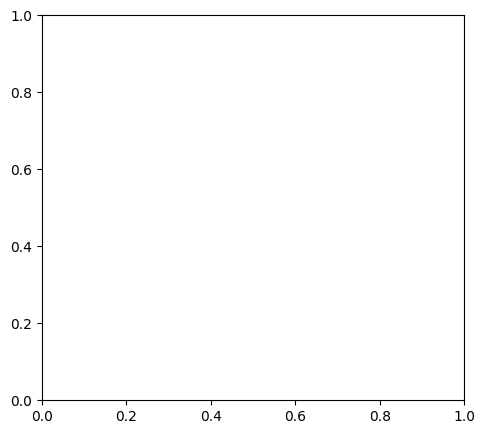

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # (rows, cols, index)
plt.plot(x_d["prcp(mm/day)"][0,:,0],label="precip",linewidth=2.0)
T_avg=(x_d['tmax(C)'][0, :,0] + x_d['tmin(C)'][0, :,0])/2
plt.plot(T_avg, label="av. Temp (in C)", linewidth=2.0)
plt.title('Meteorogical Forcings')
plt.legend()

plt.subplot(1, 2, 2) 
plt.plot(x_history[0,:],label='snow',linewidth=2.0)
plt.plot(x_history[1,:],label='fast-flow',linewidth=2.0)
plt.plot(x_history[2,:],label='unsat-zone',linewidth=2.0)
plt.plot(x_history[3,:],label='si',linewidth=2.0)
plt.plot(x_history[4,:], label = "sb", linewidth=2.0)
plt.legend()
plt.title("States")
plt.show()

plt.plot(x_history[5,:], label = "shm outflow (z-)")
plt.plot(z_plus, label = "LSTM outflow (z+)")
plt.plot(raw_data_point["y"][0,:,0], label = "Observed outflow")
plt.legend()
plt.title("Outflows")

In [ ]:
print(x_history[5,:])